## <center>CITS5508 Assignment 2</center>

Author: Seng Qi Ming (25303739)

 - [Ensemble Learning for Heart Disease Prediction](#part-1-ensemble-learning-for-heart-disease-prediction)
 - [Clustering of Faces](#part-2-clustering-of-faces)

In this assignment we will first use ensemble learning for heart disease prediction, for the next part we will explore on technique for clustering of faces.

### Importing necessary libraries

In [452]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import graphviz
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

## Part 1: Ensemble Learning for Heart Disease Prediction

In this task, we will compare a range of ensemble methods for predicting the presence of heart disease in patients.

We will use the Heart Disease dataset from the UC Irvine Machine Learning Repository, available at: https://doi.org/10.24432/C52P4X.

### 1.1: Load the dataset & Inspect the data
We will first load the dataset using the `processed.cleveland.data`, From the source, the variables are as follows
| Variable Name | Role | Type | Description | Missing Values |
|---------------|-----|------|-------------|----------------|
| age           | Feature|Integer| | No|
| sex           | Feature|Categorical| | No |
| cp            | Feature|Categorical| | No |
| trestbps      | Feature| Integer| resting blood pressure (on admission to the hospital)| No |
| chol      | Feature| Integer| serum cholestoral | No |
| fbs      | Feature| Categorical | fasting blood sugar > 120 mg/dl| No |
| restecg      | Feature| Categorical | | No |
| thalach      | Feature| Integer| maximum heart rate achieved | No |
| exang      | Feature| Categorical | exercise induced angina| No |
| oldpeak      | Feature| Integer| ST depression induced by exercise relative to rest | No |
| slope      | Feature| Categorical| | No |
| ca      | Feature| Integer| number of major vessels (0-3) colored by flourosopy| Yes |
| thal      | Feature| Categorical| | Yes |
| num      | Target| Integer| diagnosis of heart disease| No |

For the target variable, num its describes as binary (0 or 1), which is the raw measurement of whether any major vessel has greater than 50% diameter narrowing. However, the actual Cleveland data file contains integer values from 0 to 4, representing the number of major vessels with significant narrowing. Following the assignment specification, we will binarise the target: 0 = absence of heart disease, 1 = presence of heart disease (any value greater than 0).

In [453]:
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

data = pd.read_csv('processed.cleveland.data', names=column_names, na_values='?')

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [454]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [455]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [456]:
n_examples = data.shape[0]
n_features = data.shape[1]

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print(f'Number of examples: {n_examples}')
print(f'Number of features (including target): {n_features}')
print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')

data['num_binary'] = (data['num'] > 0).astype(int)
print('Target distribution (original):')
print(data['num'].value_counts().sort_index())
print('Target distribution (binary):')
print(data['num_binary'].value_counts().sort_index())

Number of examples: 303
Number of features (including target): 14
Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Target distribution (original):
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
Target distribution (binary):
num_binary
0    164
1    139
Name: count, dtype: int64


### Observation
- There are 303 examples (which mean 303 patients).
- There are 13 features (excluding the target). 
    - Numeric: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`.
    - Categorical: `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`.

#### 1.2 Splitting of dataset
Split the dataset into a training and testing set. Use 80% of the data for training, and 20% for
testing. Make sure to stratify your split. 
For row with missing values, we will drop the row

In [457]:
# We will drop the rows with missing values 
data = data.dropna()

We would do onehotencoding for the categorical data as well.

For e.g. for sex we could split it into is_male and is_female then drop one of then since 1-is_male = is_female

In [458]:
data_labeled = data.copy()

data_labeled["sex"] = data_labeled["sex"].map({0: "female", 1: "male"})
data_labeled["cp"] = data_labeled["cp"].map({
    1: "typical",
    2: "atypical",
    3: "non_anginal",
    4: "asymptomatic",
})
data_labeled["fbs"] = data_labeled["fbs"].map({0: "no", 1: "yes"})
data_labeled["restecg"] = data_labeled["restecg"].map({
    0: "normal",
    1: "st_t_abnormal",
    2: "lv_hypertrophy",
})
data_labeled["exang"] = data_labeled["exang"].map({0: "no", 1: "yes"})
data_labeled["slope"] = data_labeled["slope"].map({1: "upsloping", 2: "flat", 3: "downsloping"})
data_labeled["thal"] = data_labeled["thal"].map({3: "normal", 6: "fixed_defect", 7: "reversable_defect"})

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="if_binary")
df_encoded_np = encoder.fit_transform(data_labeled[categorical_features])

df_encoded = pd.DataFrame(
    df_encoded_np,
    columns=encoder.get_feature_names_out(categorical_features),
    index=data.index,
)

print(df_encoded)

     sex_male  cp_asymptomatic  cp_atypical  cp_non_anginal  cp_typical  \
0         1.0              0.0          0.0             0.0         1.0   
1         1.0              1.0          0.0             0.0         0.0   
2         1.0              1.0          0.0             0.0         0.0   
3         1.0              0.0          0.0             1.0         0.0   
4         0.0              0.0          1.0             0.0         0.0   
..        ...              ...          ...             ...         ...   
297       0.0              1.0          0.0             0.0         0.0   
298       1.0              0.0          0.0             0.0         1.0   
299       1.0              1.0          0.0             0.0         0.0   
300       1.0              1.0          0.0             0.0         0.0   
301       0.0              0.0          1.0             0.0         0.0   

     fbs_yes  restecg_lv_hypertrophy  restecg_normal  restecg_st_t_abnormal  \
0        1.0        

In [459]:
data_concat = pd.concat([data, df_encoded], axis=1)

data_concat = data_concat.drop(columns=categorical_features + ['num'])

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

data_concat.columns



Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'num_binary',
       'sex_male', 'cp_asymptomatic', 'cp_atypical', 'cp_non_anginal',
       'cp_typical', 'fbs_yes', 'restecg_lv_hypertrophy', 'restecg_normal',
       'restecg_st_t_abnormal', 'exang_yes', 'slope_downsloping', 'slope_flat',
       'slope_upsloping', 'thal_fixed_defect', 'thal_normal',
       'thal_reversable_defect'],
      dtype='object')

In [460]:
# Split to X and Y first 

X = data_concat.drop(columns=['num_binary'])
y = data_concat['num_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Train samples: 237, Test samples: 60


#### 1.3 Using a single Decision Tree classifier on our dataset

Fit a single Decision Tree classifier using scikit-learn as a baseline and evaluate its performance on the test set.


Clasification Report 
               precision    recall  f1-score   support

           0       0.71      0.75      0.73        32
           1       0.69      0.64      0.67        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



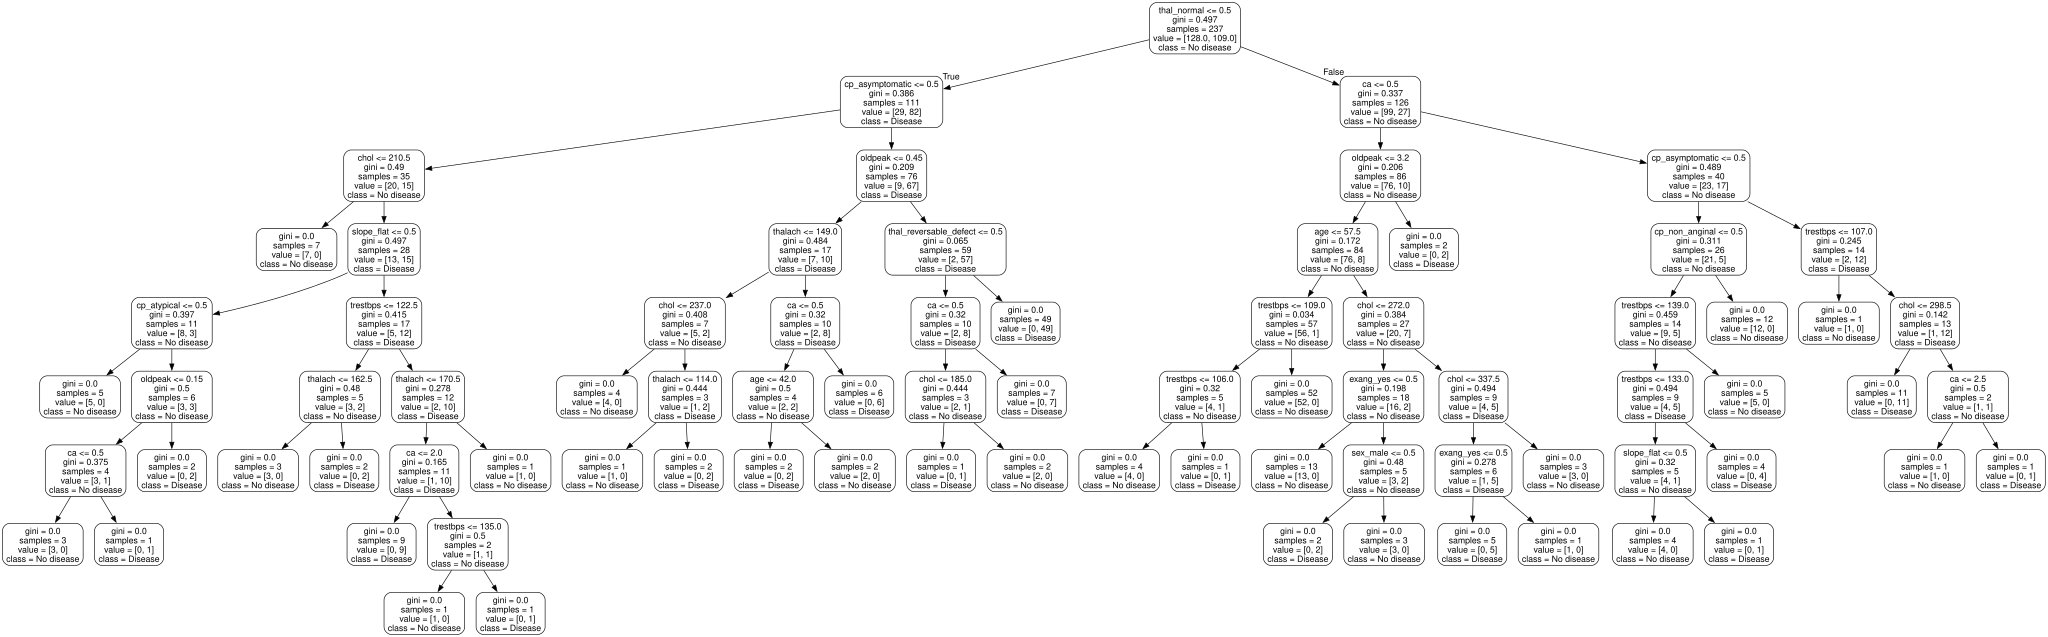

In [461]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)

print(f'\nClasification Report \n {classification_report(y_true=y_test, y_pred=y_pred)}')

tree_viz = graphviz.Source(
    tree.export_graphviz(
        dt_clf,
        feature_names=X_test.columns,
        class_names=["No disease", "Disease"],
        filled=False,
        rounded=True,
    )
)
tree_viz

#### 1.4 Fitting of Random Forest Classifier and AdaBoost Classifier

In [462]:
rf_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rf_clf.fit(X_train, y_train)

ada_clf = AdaBoostClassifier(n_estimators=500, random_state=42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=500, random_state=42)

#### 1.5 Combining both Random Forest  classifier and Adaboost Classifier using Voting Classifier

In [463]:
voting_clf = VotingClassifier(estimators=[('rf_clf', rf_clf), ('ada_clf', ada_clf)], voting='soft')

voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf_clf',
                              RandomForestClassifier(n_estimators=500,
                                                     random_state=42)),
                             ('ada_clf',
                              AdaBoostClassifier(n_estimators=500,
                                                 random_state=42))],
                 voting='soft')

#### 1.6 Comparing model performance

In [464]:
models = {'Decision Tree': dt_clf, 'Random Forest': rf_clf, 'AdaBoost': ada_clf, 'Voting Classifier':voting_clf}

reports = {}
for name, model in models.items():
    report = classification_report(y_test, model.predict(X_test), output_dict=True)
    reports[name] = pd.DataFrame(report).T  # rows: class/avg, cols: precision/recall/f1/support

side_by_side = pd.concat(reports, axis=1)
display(side_by_side)


Decision Tree                             Random Forest  \
                 precision    recall  f1-score support     precision   
0                 0.705882  0.750000  0.727273    32.0      0.823529   
1                 0.692308  0.642857  0.666667    28.0      0.846154   
accuracy          0.700000  0.700000  0.700000     0.7      0.833333   
macro avg         0.699095  0.696429  0.696970    60.0      0.834842   
weighted avg      0.699548  0.700000  0.698990    60.0      0.834087   

                                             AdaBoost                      \
                recall  f1-score    support precision    recall  f1-score   
0             0.875000  0.848485  32.000000  0.900000  0.843750  0.870968   
1             0.785714  0.814815  28.000000  0.833333  0.892857  0.862069   
accuracy      0.833333  0.833333   0.833333  0.866667  0.866667  0.866667   
macro avg     0.830357  0.831650  60.000000  0.866667  0.868304  0.866518   
weighted avg  0.833333  0.832772  60.000000  0.868889  0.866667  0.866815   

                        Voting Classifier                                 
                support         precision    recall  f1-score    support  
0             32.000000          0.823529  0.875000  0.848485  32.000000  
1             28.000000          0.846154  0.785714  0.814815  28.000000  
accuracy       0.866667          0.833333  0.833333  0.833333   0.833333  
macro avg     60.000000          0.834842  0.830357  0.831650  60.000000  
weighted avg  60.000000          0.834087  0.833333  0.832772  60.000000

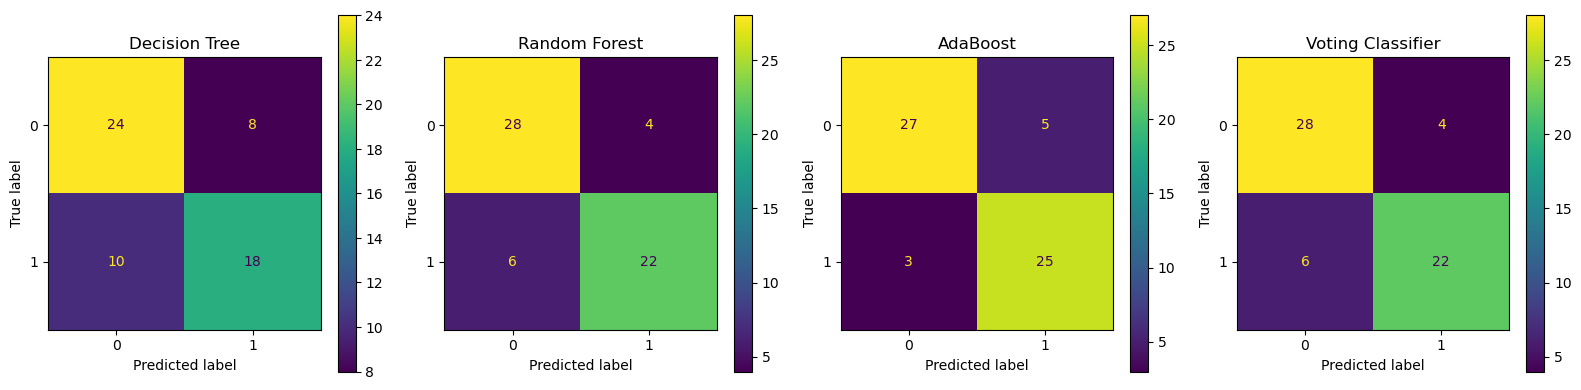

In [465]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

#### 1.7 Plot the feature importances of your Random Forest 

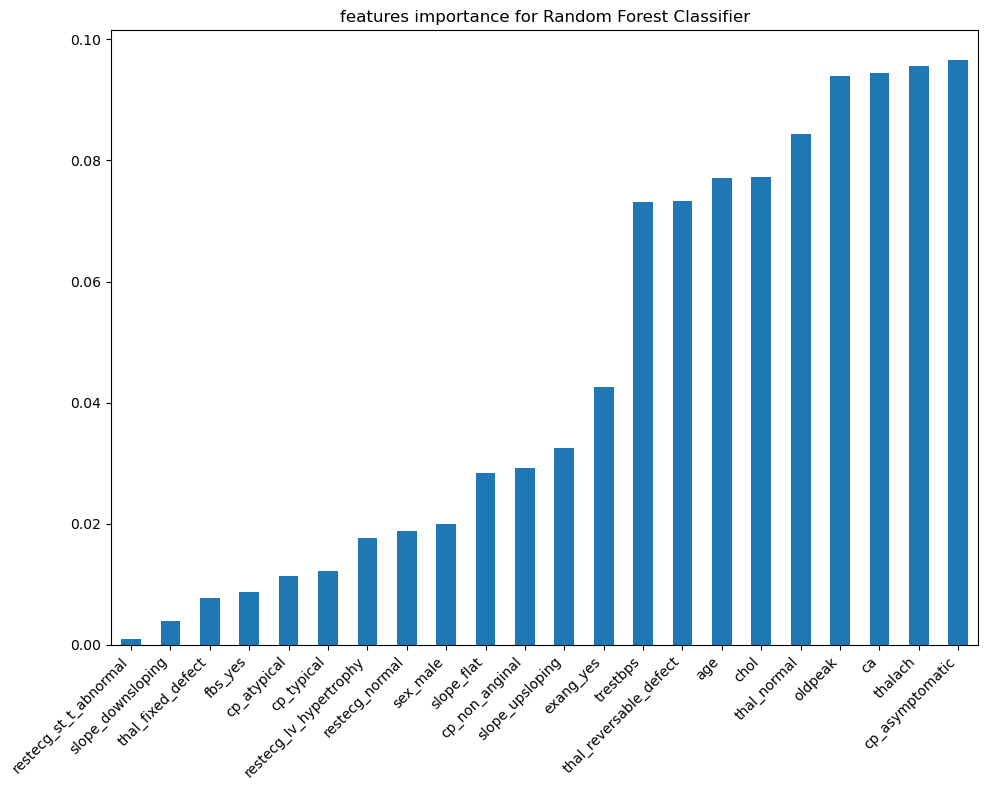

In [479]:
feat_impt = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=True)

feat_impt.plot(kind='bar', figsize=(10,8), title='features importance for Random Forest Classifier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part 2: Clustering of Faces



### 2.1 Load the dataset & Inspect the data

In [467]:
from sklearn.datasets import fetch_olivetti_faces
data, targets = fetch_olivetti_faces(return_X_y=True)

In [468]:
print(f"Number of examples: {data.shape[0]}")
print(f"Number of features: {data.shape[1]} (64x64)")
print(f"Number of classes: {len(np.unique(targets))}")
print(f"Images per class: {len(targets) // len(np.unique(targets))}")
print(f"Pixel value range: [{data.min():.1f}, {data.max():.1f}]")


Number of examples: 400
Number of features: 4096 (64x64)
Number of classes: 40
Images per class: 10
Pixel value range: [0.0, 1.0]


We got 400 examples, 4096 features
each example contains a picture of a face where each feature contain different style of a face.

### 2.2 Sample a random example from each class and display the images in a grid.

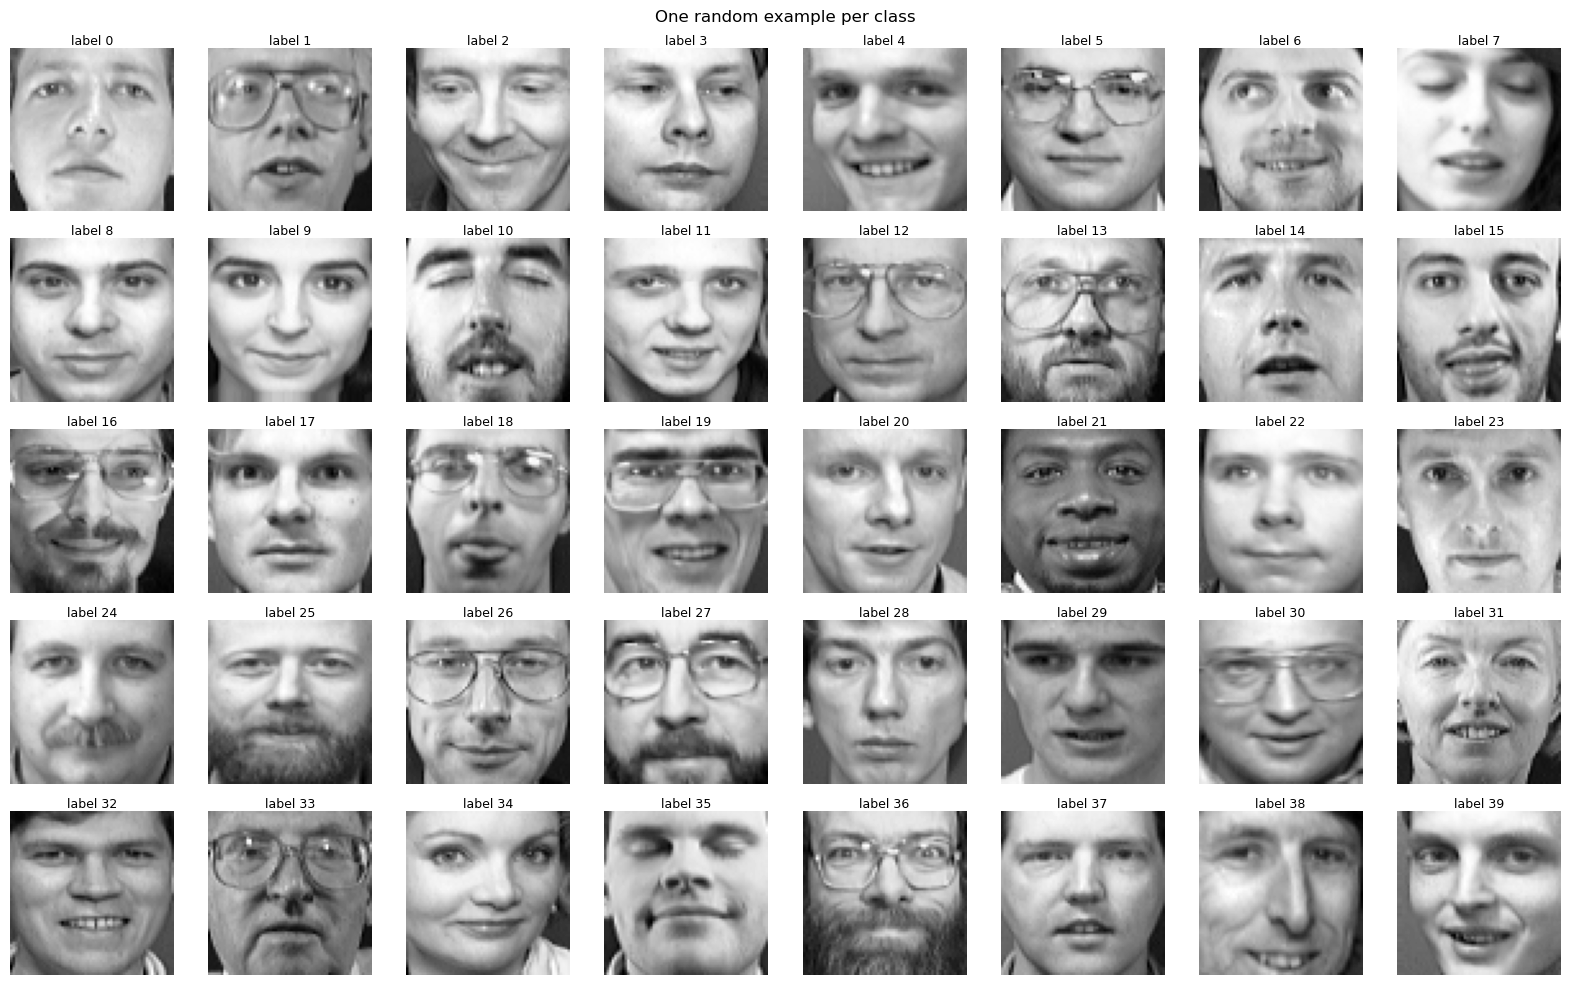

In [469]:
np.random.seed(42)

classes = np.unique(targets)
n_classes = len(classes)
n_cols = 8
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    idx = np.random.choice(np.where(targets == cls)[0])
    img = data[idx].reshape(64, 64)  # 64 * 64 = 4096
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'label {cls}', pad=2, fontsize=9)
    axes[i].axis('off')

for j in range(n_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('One random example per class')
plt.tight_layout()
plt.show()

### 2.3 Fit Principal Component Analysis (PCA) on the full dataset using scikit-learn.

In [470]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(data)

PCA(random_state=42)

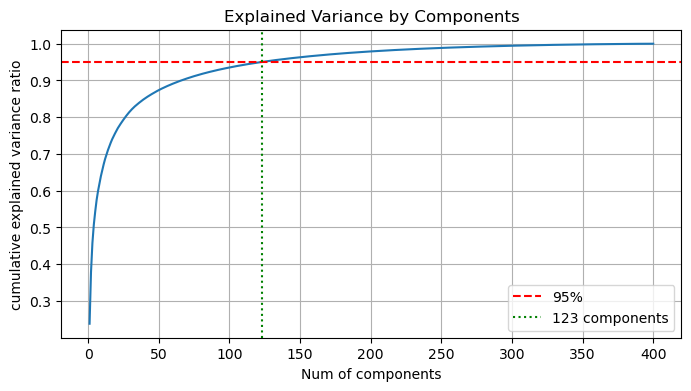

In [471]:
# Calculate the min number of components to ensure it retains at least 95% of the variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

# data_reduced = pca.fit_transform(X=data)
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(cumsum) + 1), cumsum, linewidth=1.5)
plt.axhline(0.95, color="r", linestyle="--", label="95%")
plt.axvline(d, color="g", linestyle=":", label=f"{d} components")
plt.xlabel('Num of components')
plt.ylabel('cumulative explained variance ratio')
plt.title('Explained Variance by Components')
plt.legend()
plt.grid(True)
plt.show()

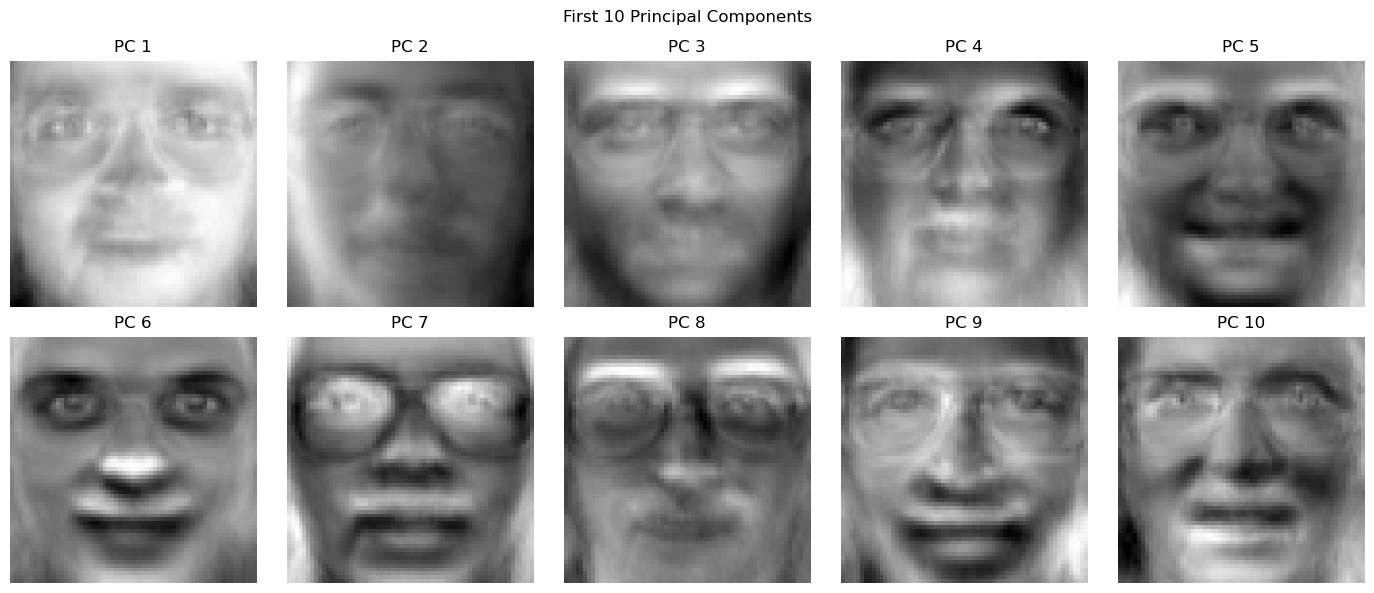

In [472]:
fig, axes = plt.subplots(2,5, figsize=(14, 6))
for idx, axes in enumerate(axes.flatten()):
    img = pca.components_[idx].reshape(64, 64)  # 64 * 64 = 4096
    axes.imshow(img,  cmap='gray')
    axes.set_title(f'PC {idx + 1}', pad=6)
    axes.axis('off')
plt.suptitle('First 10 Principal Components')
plt.subplots_adjust(hspace=0.4, top=0.88)
plt.tight_layout()
plt.show()

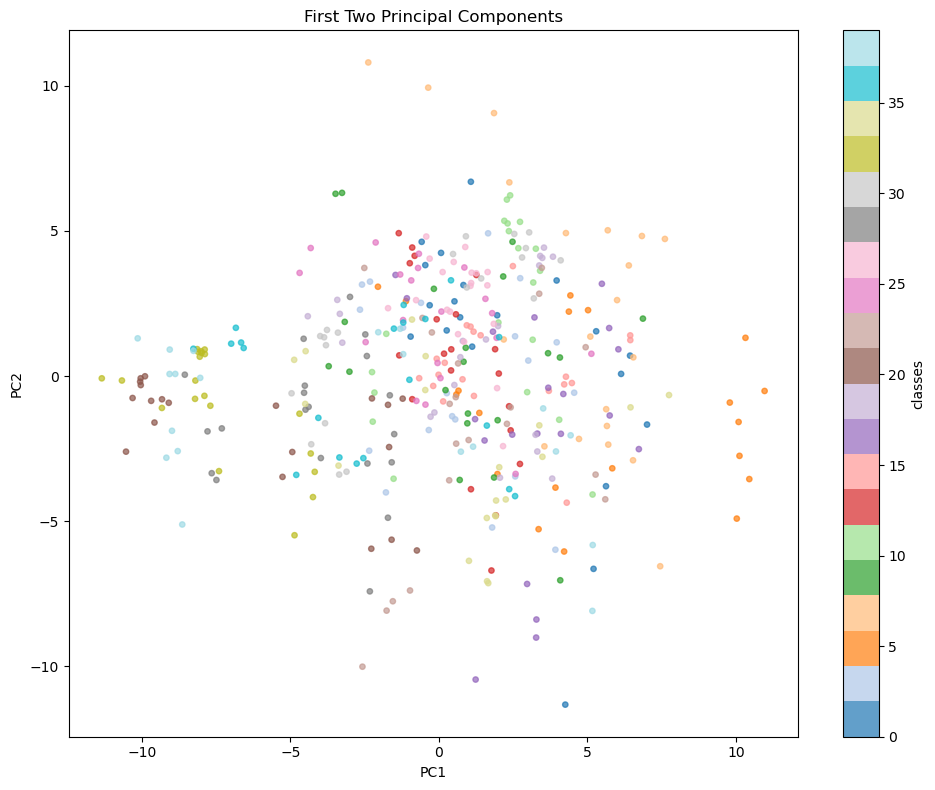

In [473]:
# Project the data onto the first two principal components and produce a scatter plot, colouring each point by its class.
data_2d = pca.transform(data)[:, :2]

plt.figure(figsize=(10,8))
plt.scatter(data_2d[:,0],data_2d[:,1], c=targets, cmap="tab20", s=15, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("First Two Principal Components")
plt.colorbar(label='classes')
plt.tight_layout()
plt.show()

In [474]:
# Number of classes: 40
k = 40
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(data)

score = silhouette_score(data, kmeans.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.12942751


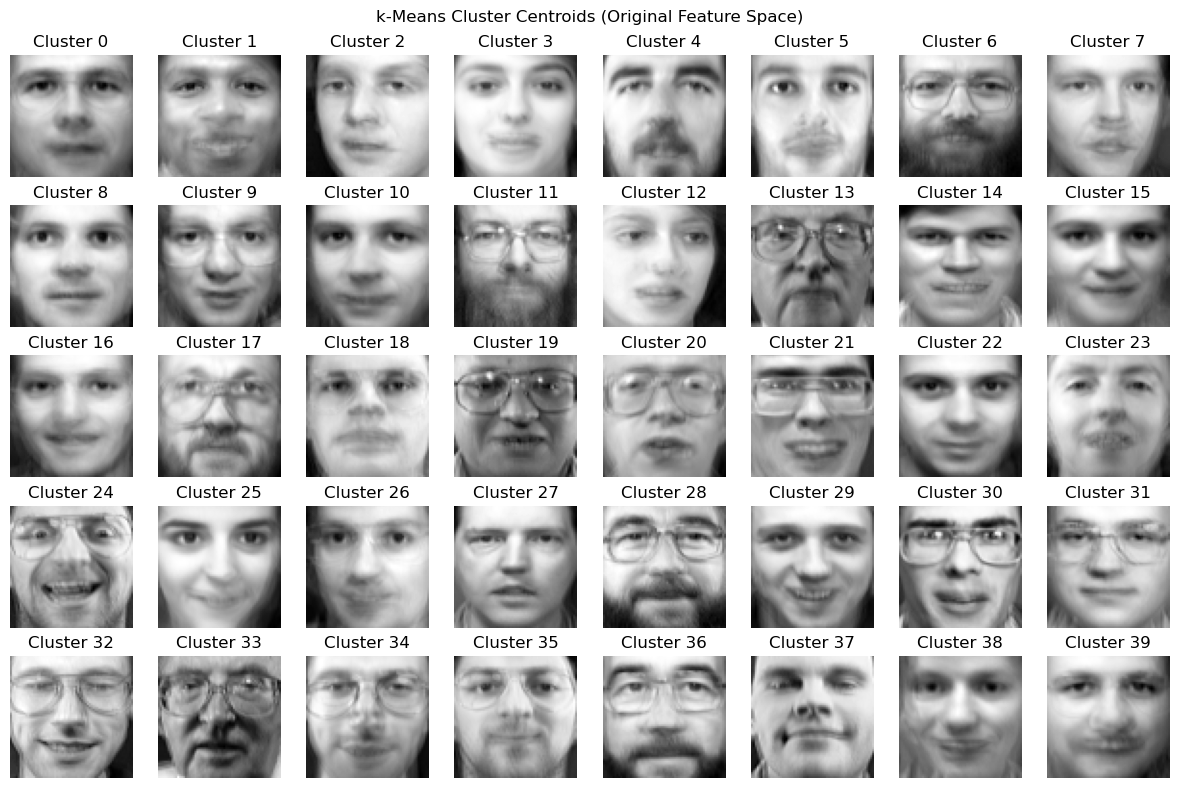

In [475]:
fig, axes = plt.subplots(5, 8, figsize=(12, 8))
for idx, ax in enumerate(axes.flat):
    ax.imshow(kmeans.cluster_centers_[idx].reshape(64,64), cmap='gray')
    ax.set_title(f'Cluster {idx}')
    ax.axis('off') 

plt.suptitle('k-Means Cluster Centroids (Original Feature Space)')
plt.tight_layout()
plt.show()

In [476]:
data_reduced = pca.transform(data)[:, :d]

kmeans_pca = KMeans(n_clusters=k, random_state=42)
kmeans_pca.fit(data_reduced)

score_pca = silhouette_score(data_reduced, kmeans_pca.labels_)
print("Silhouette Score:", score_pca)

Silhouette Score: 0.17359658


Without pca: 0.12942750751972198 
 with pca: 0.1735965758562088


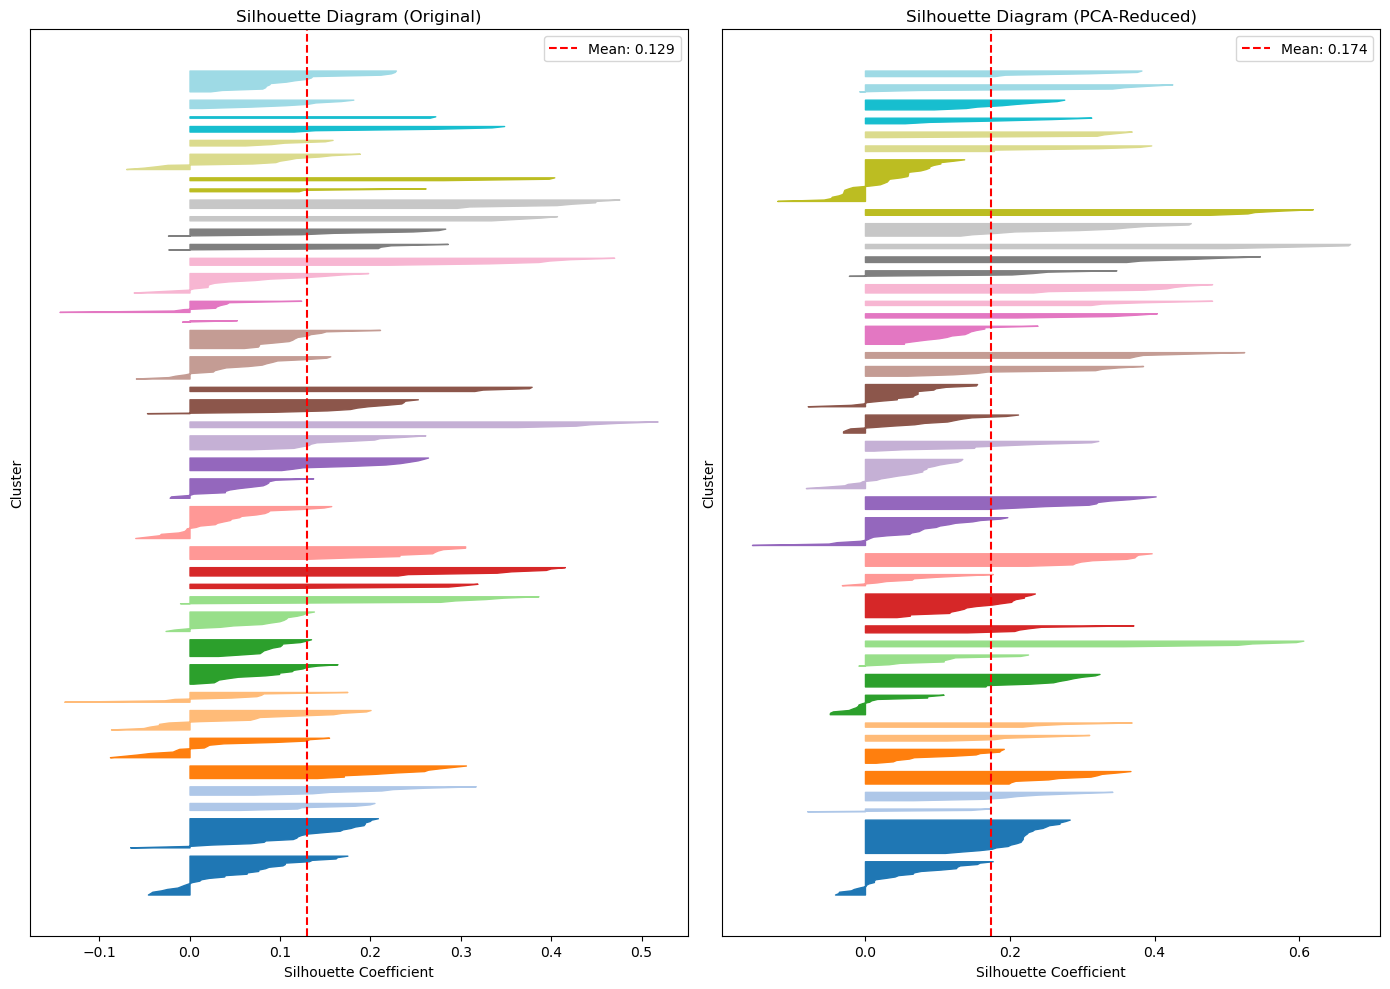

In [477]:
print(f'Without pca: {score} \n with pca: {score_pca}')

def plot_silhouette_graph(data, labels, score, title, ax):
    n_cluster = len(np.unique(labels))
    silhouette_values = silhouette_samples(data, labels)
    y_lower = 10

    for i in range(n_cluster):
        cluster_vals = np.sort(silhouette_values[labels == i])
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        color = cm.tab20(i / n_cluster)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, color=color)
        y_lower = y_upper + 5
    ax.axvline(x=score, color='red', linestyle='--', label=f'Mean: {score:.3f}')
    ax.set_title(title)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14,10))
plot_silhouette_graph(data, kmeans.labels_, score, 'Silhouette Diagram (Original)', axes[0])
plot_silhouette_graph(data_reduced, kmeans_pca.labels_, score_pca, 'Silhouette Diagram (PCA-Reduced)', axes[1])
plt.tight_layout()
plt.show()

,Original,PCA-Reduced,Improvement
Metric,,,
Silhouette Score,0.129428,0.173597,+34.1%
Adjusted Rand Index,0.430132,0.413121,-4.0%
Normalized Mutual Info,0.772936,0.775245,+0.3%
Macro F1 (aligned),0.542972,0.523912,-3.5%
Inertia (SSE),12539.197266,10616.100586,-15.3%


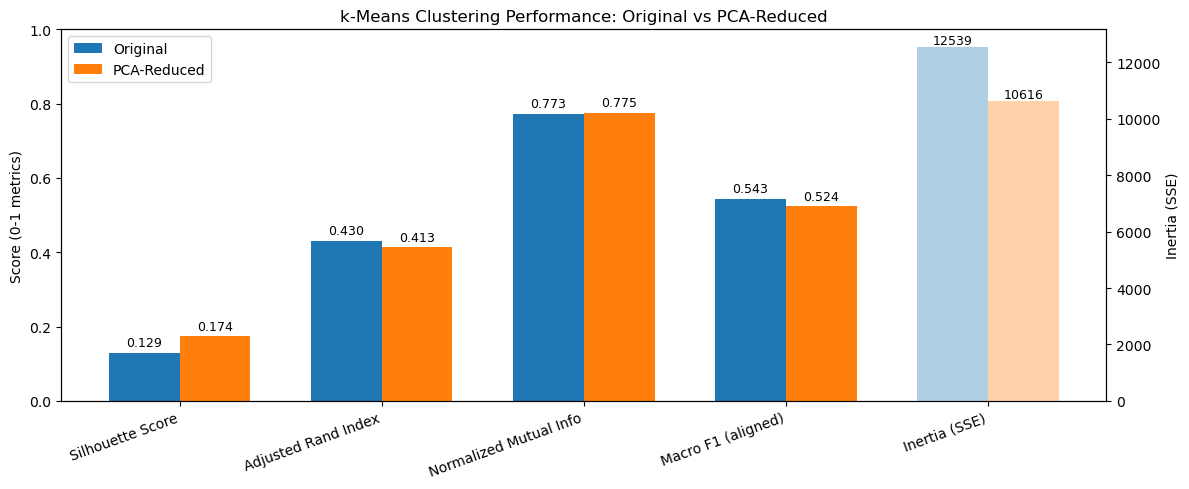

In [478]:
from sklearn.metrics import f1_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

def clustering_accuracy_f1(true_labels, cluster_labels):
    # Map cluster IDs to true labels using Hungarian assignment
    confusion = contingency_matrix(true_labels, cluster_labels)
    row_ind, col_ind = linear_sum_assignment(-confusion)
    mapped_labels = np.zeros_like(cluster_labels)
    for r, c in zip(row_ind, col_ind):
        mapped_labels[cluster_labels == c] = r
    f1 = f1_score(true_labels, mapped_labels, average="macro")
    return f1

f1_orig = clustering_accuracy_f1(targets, kmeans.labels_)
f1_pca = clustering_accuracy_f1(targets, kmeans_pca.labels_)

metrics = {
    "Metric": [
        "Silhouette Score",
        "Adjusted Rand Index",
        "Normalized Mutual Info",
        "Macro F1 (aligned)",
        "Inertia (SSE)",
    ],
    "Original": [
        score,
        adjusted_rand_score(targets, kmeans.labels_),
        normalized_mutual_info_score(targets, kmeans.labels_),
        f1_orig,
        kmeans.inertia_,
    ],
    "PCA-Reduced": [
        score_pca,
        adjusted_rand_score(targets, kmeans_pca.labels_),
        normalized_mutual_info_score(targets, kmeans_pca.labels_),
        f1_pca,
        kmeans_pca.inertia_,
    ],
}

df_metrics = pd.DataFrame(metrics).set_index("Metric")
df_metrics["Improvement"] = (
    (df_metrics["PCA-Reduced"] - df_metrics["Original"])
    / df_metrics["Original"]
    * 100
).map("{:+.1f}%".format)
display(df_metrics)

metric_labels = df_metrics.index.tolist()
base_metrics = metric_labels[:-1]
inertia_label = metric_labels[-1]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()

# 0-1 metrics on left axis
base_x = x[: len(base_metrics)]
bars1 = ax.bar(base_x - width / 2, df_metrics.loc[base_metrics, "Original"], width, label="Original")
bars2 = ax.bar(base_x + width / 2, df_metrics.loc[base_metrics, "PCA-Reduced"], width, label="PCA-Reduced")
ax.set_ylim(0, 1)
ax.set_ylabel("Score (0-1 metrics)")

# Inertia on right axis
inertia_x = x[len(base_metrics)]
bars3 = ax2.bar(inertia_x - width / 2, df_metrics.loc[inertia_label, "Original"], width, color="#1f77b4", alpha=0.35)
bars4 = ax2.bar(inertia_x + width / 2, df_metrics.loc[inertia_label, "PCA-Reduced"], width, color="#ff7f0e", alpha=0.35)
ax2.set_ylabel("Inertia (SSE)")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=20, ha="right")
ax.set_title("k-Means Clustering Performance: Original vs PCA-Reduced")
ax.legend(loc="upper left")

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
for bar in list(bars3) + list(bars4):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

- Silhouette score: How well each point fits its own cluster compared to other clusters. Ranges from -1 to 1; higher is better.
- ARI (Adjusted Rand Index): Measures agreement between clustering and true labels, corrected for chance. 0 is random, 1 is perfect.
- NMI (Normalized Mutual Information): Measures how much information the cluster labels share with true labels, normalized to 0-1.
- Macro F1 (aligned): Treats clustering like classification by matching cluster IDs to true labels, then computes average F1 across classes. 0-1; higher is better.
- Inertia (SSE): Sum of squared distances to the nearest centroid. Lower is better.